In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy as sp

In [3]:
df=pd.read_csv('/content/ai_jobs_market_2025_2026.csv')
print(df)

         job_id               job_title      job_category  experience_level  \
0     AIJOB0001      AI Agent Developer    AI Engineering  Senior (6-9 yrs)   
1     AIJOB0002         Prompt Engineer    AI Engineering  Senior (6-9 yrs)   
2     AIJOB0003            LLM Engineer    AI Engineering  Senior (6-9 yrs)   
3     AIJOB0004      Data Engineer (AI)  Data Engineering  Senior (6-9 yrs)   
4     AIJOB0005      AI Product Manager           Product    Lead (10+ yrs)   
...         ...                     ...               ...               ...   
1495  AIJOB1496  Multimodal AI Engineer    AI Engineering    Lead (10+ yrs)   
1496  AIJOB1497            NLP Engineer    AI Engineering  Senior (6-9 yrs)   
1497  AIJOB1498   AI Compliance Manager        Governance     Mid (3-5 yrs)   
1498  AIJOB1499            NLP Engineer    AI Engineering    Lead (10+ yrs)   
1499  AIJOB1500    AI Security Engineer          Security    Lead (10+ yrs)   

      years_of_experience    education_required  an

In [4]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [5]:
df['annual_salary_usd']=pd.to_numeric(df['annual_salary_usd'])
print(df['annual_salary_usd'])

0       239000.0
1       166000.0
2       360000.0
3       161000.0
4       283000.0
          ...   
1495    262000.0
1496    163000.0
1497    127000.0
1498    145000.0
1499    229000.0
Name: annual_salary_usd, Length: 1500, dtype: float64


In [6]:
data=df[['job_title','job_category','years_of_experience','city','country','annual_salary_usd','demand_score','is_senior','remote_work','is_remote_friendly','is_llm_role','salary_tier']]
df1=pd.DataFrame(data)
df1.head()

,job_title,job_category,years_of_experience,city,country,annual_salary_usd,demand_score,is_senior,remote_work,is_remote_friendly,is_llm_role,salary_tier
0,AI Agent Developer,AI Engineering,7,Boston,USA,239000.0,96,1,On-site,0,1,Senior ($200-300k)
1,Prompt Engineer,AI Engineering,2,London,UK,166000.0,82,1,Hybrid,1,1,Upper-Mid ($150-200k)
2,LLM Engineer,AI Engineering,4,Seattle,USA,360000.0,98,1,Fully Remote,1,1,Elite (>$300k)
3,Data Engineer (AI),Data Engineering,3,Singapore,Singapore,161000.0,88,1,Fully Remote,1,0,Upper-Mid ($150-200k)
4,AI Product Manager,Product,5,Los Angeles,USA,283000.0,85,1,Fully Remote,1,0,Senior ($200-300k)


In [7]:
print(df1['job_title'].value_counts())

job_title
LLM Engineer                75
Robotics Engineer (AI)      74
Prompt Engineer             71
Generative AI Engineer      71
AI Product Manager          70
Multimodal AI Engineer      67
Senior Data Scientist       66
AI Compliance Manager       66
Senior ML Engineer          64
AI Engineer                 64
AI Business Analyst         62
Data Scientist              61
Deep Learning Engineer      58
AI Agent Developer          57
AI Ethics Officer           56
ML Engineer                 55
NLP Engineer                55
AI Infrastructure Eng       55
RAG Engineer                53
AI Solutions Architect      52
Data Engineer (AI)          51
MLOps Engineer              51
AI Security Engineer        50
AI Research Scientist       50
Computer Vision Engineer    46
Name: count, dtype: int64


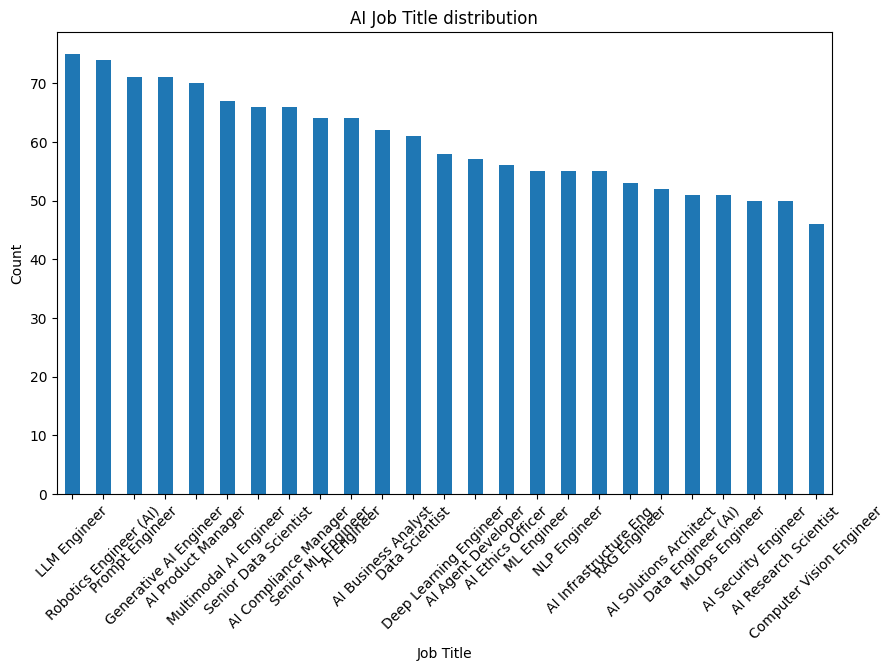

In [8]:
job_counts=df1['job_title'].value_counts()
annual_salary=df1['annual_salary_usd'].value_counts().head(20)
plt.figure(figsize=(10,6))
job_counts.plot(kind='bar')
plt.title("AI Job Title distribution")
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [9]:
df.groupby('experience_level')['annual_salary_usd'].mean()

,annual_salary_usd
experience_level,
Entry (0-2 yrs),150038.961039
Lead (10+ yrs),240055.118110
Mid (3-5 yrs),175983.783784
Senior (6-9 yrs),214280.219780


In [10]:
df.sort_values(by='experience_level')[['job_title','experience_level']].value_counts().head(10)

job_title               experience_level
Senior ML Engineer      Senior (6-9 yrs)    26
AI Engineer             Lead (10+ yrs)      22
AI Compliance Manager   Senior (6-9 yrs)    22
AI Product Manager      Lead (10+ yrs)      22
LLM Engineer            Senior (6-9 yrs)    22
                        Entry (0-2 yrs)     21
Generative AI Engineer  Mid (3-5 yrs)       21
Prompt Engineer         Entry (0-2 yrs)     21
Robotics Engineer (AI)  Entry (0-2 yrs)     21
AI Business Analyst     Entry (0-2 yrs)     21
Name: count, dtype: int64

In [11]:
strr=df['required_skills'].str.split('|').explode().value_counts()
print(strr)

required_skills
Python                     942
SQL                        452
Cloud                      429
Leadership                 380
Communication              378
                          ... 
Risk Assessment             34
OpenCV                      34
ETL                         33
Spark                       31
Enterprise Architecture     31
Name: count, Length: 93, dtype: int64


In [12]:
df[['job_title', 'company_size','experience_level']].value_counts().head()

job_title               company_size         experience_level
Senior ML Engineer      Startup (1-50)       Mid (3-5 yrs)       8
LLM Engineer            Mid-size (501-5000)  Entry (0-2 yrs)     8
                        Big Tech (FAANG+)    Senior (6-9 yrs)    8
AI Solutions Architect  Startup (1-50)       Entry (0-2 yrs)     8
Prompt Engineer         Big Tech (FAANG+)    Lead (10+ yrs)      8
Name: count, dtype: int64

In [13]:
df.sort_values(by='required_skills')[['industry']].value_counts()


,count
industry,
Automotive,138
Healthcare,138
Government,136
Finance,131
Retail,131
Energy,130
Consulting,126
Education,120
Media,120


In [14]:
df['country'].value_counts()

,count
country,
USA,515
UK,90
China,87
Canada,85
Global,82
Germany,81
Australia,78
Switzerland,76
Japan,76


In [15]:
df['is_llm_role'].value_counts()

,count
is_llm_role,
0,1173
1,327


In [16]:
df['remote_work'].value_counts()

,count
remote_work,
Hybrid,686
Fully Remote,445
On-site,369


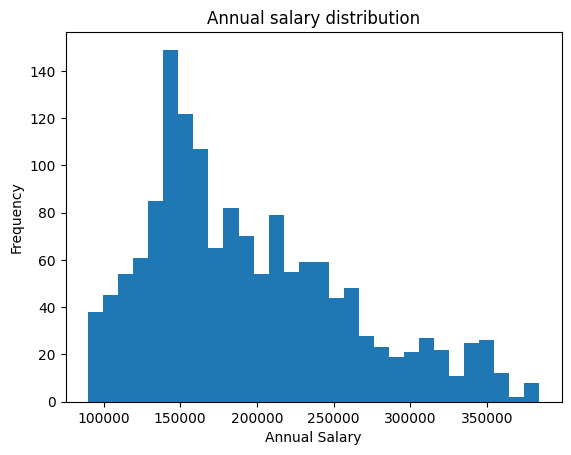

In [17]:
plt.hist(df['annual_salary_usd'],bins=30)
plt.title('Annual salary distribution')
plt.xlabel('Annual Salary')
plt.ylabel('Frequency')
plt.show()

<Axes: ylabel='job_title'>

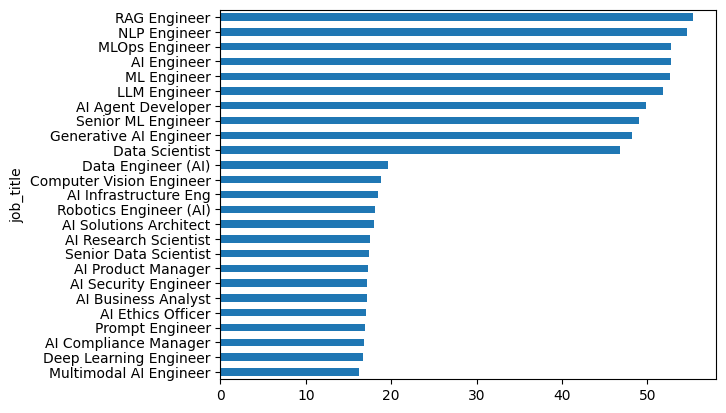

In [18]:
df.groupby('job_title')['demand_growth_yoy_pct'].mean().sort_values().plot(kind='barh')


In [19]:
df[['annual_salary_usd','demand_score','benefits_score_10']].corr()

,annual_salary_usd,demand_score,benefits_score_10
annual_salary_usd,1.000000,0.291800,-0.014715
demand_score,0.291800,1.000000,-0.001334
benefits_score_10,-0.014715,-0.001334,1.000000
